# 📊 Telco Customer Churn Analysis

## Business Problem

A telecommunications company is experiencing customer churn and wants to understand why customers are leaving. The objective is to analyze customer behavior, identify the key factors associated with churn, and build a machine learning model capable of predicting whether a customer is likely to leave the company.

---

## Project Objectives

- Understand the dataset and each feature.
- Identify data quality issues.
- Explore customer churn patterns.
- Perform feature engineering.
- Build and evaluate predictive models.
- Provide business recommendations to improve customer retention.

## Import Required Libraries

In this section, we import the libraries required for data manipulation, numerical computations, and visualization throughout the project.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# Improve plot appearance
plt.style.use("ggplot")

## Load the Dataset

The dataset is loaded from the **data** directory. This dataset contains customer demographic information, services subscribed, account details, and whether the customer churned.

In [4]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Initial Observations

The dataset has been loaded successfully. The first five records provide an initial understanding of customer information, subscribed services, billing details, and the target variable (`Churn`).

## Dataset Shape

The shape of the dataset tells us the total number of rows (observations) and columns (features). This helps us understand the size of the dataset before analysis.

In [5]:
print("Dataset Shape:", df.shape)

print(f"\nNumber of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Dataset Shape: (7043, 21)

Number of Rows    : 7043
Number of Columns : 21


## Dataset Information

The `info()` method provides a quick overview of the dataset, including column names, data types, number of non-null values, and memory usage. This helps identify potential data quality issues such as missing values and incorrect data types.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## First and Last Five Records

Displaying both the first and last five records helps verify that the dataset has been loaded correctly and provides an initial understanding of the available data.

In [7]:
print("First 5 Rows")
display(df.head())

print("\nLast 5 Rows")
display(df.tail())

First 5 Rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Last 5 Rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## Column Names

Listing all column names provides an overview of the available features and helps us understand what information is available for analysis.

In [8]:
print("Total Columns:", len(df.columns))
print()

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Total Columns: 21

1. customerID
2. gender
3. SeniorCitizen
4. Partner
5. Dependents
6. tenure
7. PhoneService
8. MultipleLines
9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn


## Observations

- The dataset contains **7,043 customer records**.
- There are **21 columns**, including customer information, subscribed services, billing details, and the target variable (`Churn`).
- The dataset size is sufficient for performing exploratory data analysis and building a machine learning model.

## Observations

- The dataset contains **7,043 observations** and **21 features**.
- Based on `df.info()`, there are **18 categorical features**, **2 integer features**, and **1 floating-point feature**.
- No missing values are detected based on non-null counts.
- However, the **TotalCharges** column has the `object` data type even though it represents monetary values. This suggests that the column may contain invalid or blank entries and should be investigated during data cleaning.

## Missing Values

Checking for missing values helps identify incomplete records that may affect data analysis and model performance.

In [9]:
# Check missing values
missing_values = df.isnull().sum()

missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Duplicate Records

Duplicate records can introduce bias into the analysis and should be identified before model development.

In [10]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


## Missing Values

Missing values can negatively affect data analysis and machine learning models. In this section, we check whether any columns contain missing values.

In [11]:
# Check missing values in each column
missing_values = df.isnull().sum()

missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


## Duplicate Records

Duplicate records can introduce bias into the analysis. Therefore, we check whether duplicate customer records exist in the dataset.

In [13]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


## Statistical Summary

The statistical summary provides descriptive statistics for the numerical variables, helping us understand their distribution, central tendency, and spread.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [16]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### Observations

- No explicit missing values were detected using `isnull()`.
- All 21 columns contain complete records.
- However, this does not necessarily mean the dataset is completely clean.
- Some datasets use blank strings (`""`) or whitespace (`" "`) instead of `NaN`, which will be investigated during the data cleaning phase.

### Observations

- No duplicate customer records were found.
- Each row appears to represent a unique customer.

### Observations

- Only three numerical variables are currently recognized.
- `TotalCharges` is missing from the numerical summary because it is stored as an object instead of a numeric data type.
- This indicates that the column requires further investigation during the data cleaning phase.

## Key Findings

- The dataset contains **7,043 customer records** and **21 features**.
- No explicit missing values were detected.
- No duplicate records were found.
- Most variables are categorical.
- `TotalCharges` is stored as an object instead of a numeric data type and requires further investigation.
- The target variable (`Churn`) appears to be imbalanced, with "No" occurring more frequently than "Yes".

## Target Variable Analysis

The target variable is **Churn**, which indicates whether a customer has left the company. Understanding its distribution helps determine whether the dataset is balanced and provides insight into the business problem.

In [17]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [18]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


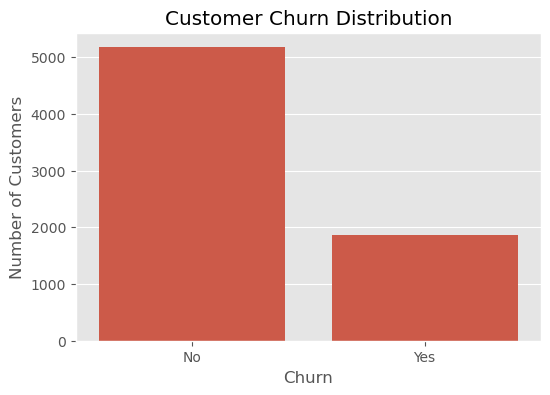

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Business Interpretation

- The majority of customers belong to one class.
- This indicates that the target variable is not perfectly balanced.
- Class imbalance should be considered during model evaluation.
- Appropriate evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC may be more informative than accuracy alone.

# Data Cleaning

## Objective

The purpose of this phase is to identify and resolve data quality issues before performing exploratory data analysis and machine learning. A clean dataset improves the reliability of insights and model performance.

## Inspecting the `TotalCharges` Column

During the data understanding phase, we observed that the `TotalCharges` column is stored as an `object` data type, even though it represents monetary values. This section investigates the reason behind this issue.

In [20]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [21]:
df["TotalCharges"].dtype

dtype('O')

In [22]:
# Check for blank or whitespace values
blank_values = (df["TotalCharges"].str.strip() == "").sum()

print(f"Blank values in TotalCharges: {blank_values}")

Blank values in TotalCharges: 11


## Technical Observation

- The `TotalCharges` column is stored as an `object` instead of a numeric data type.
- Investigation revealed **11 blank (whitespace) values** in the column.
- These blank values are not detected by `isnull()` because they are empty strings rather than actual `NaN` values.
- The presence of these blank values prevents pandas from automatically recognizing the column as numeric.

## Business Interpretation

`TotalCharges` represents the total amount a customer has paid to the company. Since this is a financial variable, it must be stored as a numeric data type.

If left uncorrected, this issue would prevent numerical analysis, correlation calculations, visualizations, and machine learning models from using this important feature correctly.

## Replacing Blank Values

Blank strings in the `TotalCharges` column are replaced with `NaN` so that they can be handled as missing values in later steps.

In [23]:
import numpy as np

# Replace blank strings with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [29]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [28]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [26]:
df["TotalCharges"].dtype

dtype('float64')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Technical Observation

- The `TotalCharges` column was successfully converted from `object` to `float64`.
- A total of **11 blank values** were identified and converted into missing (`NaN`) values.
- After conversion, the column contains **7032 valid numeric values** and **11 missing values**.
- The dataset is now ready for proper missing value handling.

## Business Interpretation

The `TotalCharges` feature represents the total amount paid by a customer over their relationship with the company.

Converting this feature to a numeric format allows it to be used in:
- Statistical analysis
- Correlation analysis
- Data visualization
- Machine learning models

Without this correction, valuable customer billing information would not be available for predictive analysis.

## Handling Missing Values

The `TotalCharges` column contains only **11 missing values**, representing approximately **0.16%** of the dataset.

Since this is a very small proportion and these records correspond to customers without valid total charges, these rows will be removed instead of imputing artificial values.

In [30]:
# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"])

In [31]:
print(df.shape)

print(df.isnull().sum().sum())

(7032, 21)
0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [33]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7032, 21)


In [34]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [35]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### Key Observations

- Converted `TotalCharges` from `object` to `float64`.
- Identified and removed 11 records with missing `TotalCharges`.
- The cleaned dataset contains **7032 records**.
- No missing values or duplicate records remain.
- The dataset is now ready for Exploratory Data Analysis.